## 1. Business Understanding

The goal of this project is to analyze data from the Stack Overflow Developer Survey
to understand factors that influence developer salaries and to build a machine learning
model that predicts whether a developer earns above the median salary.

### Business Questions

1. How does professional coding experience relate to salary?
2. What is the distribution of developer salaries in the survey?
3. Are more experienced developers more likely to earn above the median salary?
4. Can we predict whether a developer earns above the median salary using experience?

## 2. Data Understanding (Exploratory Data Analysis)

In [26]:
df = pd.read_csv("survey_results_public.csv")
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [6]:
df.shape

(65437, 114)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [8]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [9]:
df.isnull().mean().sort_values(ascending=False).head(10)

,0
AINextMuch less integrated,0.982456
AINextLess integrated,0.964011
AINextNo change,0.809007
AINextMuch more integrated,0.794642
EmbeddedAdmired,0.744288
EmbeddedWantToWorkWith,0.731039
EmbeddedHaveWorkedWith,0.660528
ConvertedCompYearly,0.641869
AIToolNot interested in Using,0.626908
AINextMore integrated,0.626694


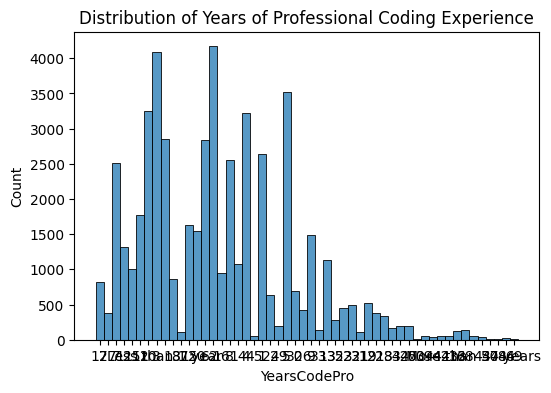

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['YearsCodePro'].dropna(), bins=30)
plt.title("Distribution of Years of Professional Coding Experience")
plt.show()

## 3. Data Preparation

The dataset contains missing values and non-numeric entries that must be cleaned
before training a machine learning model. Only relevant columns are selected to
simplify the modeling process.

In [27]:
df_model = df[['YearsCodePro', 'ConvertedCompYearly']].dropna()

In [28]:
def convert_years_code_pro(value):
    """
    Converts YearsCodePro values to numeric format.
    """
    if value == "Less than 1 year":
        return 0.5
    elif value == "More than 50 years":
        return 50
    else:
        return float(value)

df_model['YearsCodeProNumeric'] = df_model['YearsCodePro'].apply(convert_years_code_pro)

In [29]:
median_salary = df_model['ConvertedCompYearly'].median()

df_model['AboveMedianSalary'] = (
    df_model['ConvertedCompYearly'] > median_salary
).astype(int)

## 4. Modeling

In [30]:
X = df_model[['YearsCodeProNumeric']]
y = df_model['AboveMedianSalary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## 5. Evaluation

In [31]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

accuracy, precision, recall

(0.6686656671664168, 0.6995905834186285, 0.5874516544907606)

Accuracy measures the percentage of correct predictions.
Precision shows how many predicted high earners actually earn above the median.
Recall measures how well the model identifies all high earners.

## 6. Prediction Scenario

Consider a developer with 5 years of professional coding experience.
The trained model is used to predict whether this developer earns
above the median salary.

In [32]:
model.predict([[5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

The model outputs a binary prediction, where 1 indicates earnings above the median
and 0 indicates earnings below the median.

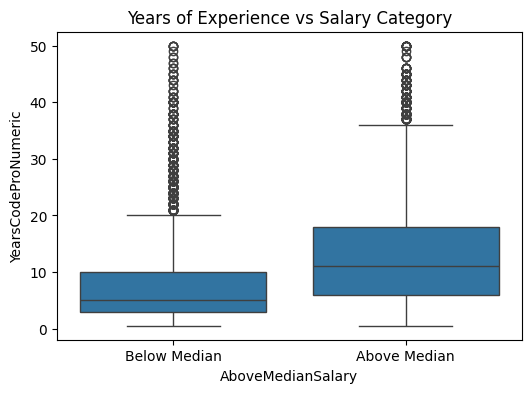

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x=df_model['AboveMedianSalary'],
    y=df_model['YearsCodeProNumeric']
)
plt.xticks([0, 1], ['Below Median', 'Above Median'])
plt.title("Years of Experience vs Salary Category")
plt.show()

## 7. Conclusion

This analysis showed that professional coding experience is strongly related to
developer salary. Using a logistic regression model, it was possible to predict
whether a developer earns above the median salary with reasonable accuracy.
These findings help highlight the importance of experience in compensation outcomes.